
# Bayesian model selection

An overview of Bayesian model selection combining gammapy with ultranest and arziv packages. 


## Context

For a general overview see:
- https://arviz-devs.github.io/EABM/Chapters/Model_comparison.html
- https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html

Here we are going to focus on the following questions:
- What are the comon information criterion used for model selection nowadays  ?
- how the parameter posterior is sensitive to the choice of prior ?
- how model comparison is sensitive to the choice of prior ?


## Proposed approach

In this example, we will perform a Bayesian analysis with multiple 1D
spectra of the Crab nebula data. Then we will discuss how to interpret the posterior
distributions, the sensitivity to prior of the different information criterion used for model selection, and how to define the priors.




## Setup

As usual, we’ll start with some setup …




In [1]:
# imports
import numpy as np
from gammapy.datasets import Datasets
from gammapy.datasets import SpectrumDatasetOnOff

from gammapy.modeling.models import (
    SkyModel,
    UniformPrior,
    LogUniformPrior,
    GaussianPrior,
)
import arviz as az
from gammapy.modeling.sampler import Sampler

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Loading the spectral datasets

Here we will load a few Crab 1D spectral data for which we will do a
fit.




In [2]:
path = "$GAMMAPY_DATA/joint-crab/spectra/hess/"

datasets = Datasets()
for id in ["23523", "23526", "23559", "23592"]:
    dataset = SpectrumDatasetOnOff.read(f"{path}pha_obs{id}.fits")
    datasets.append(dataset)

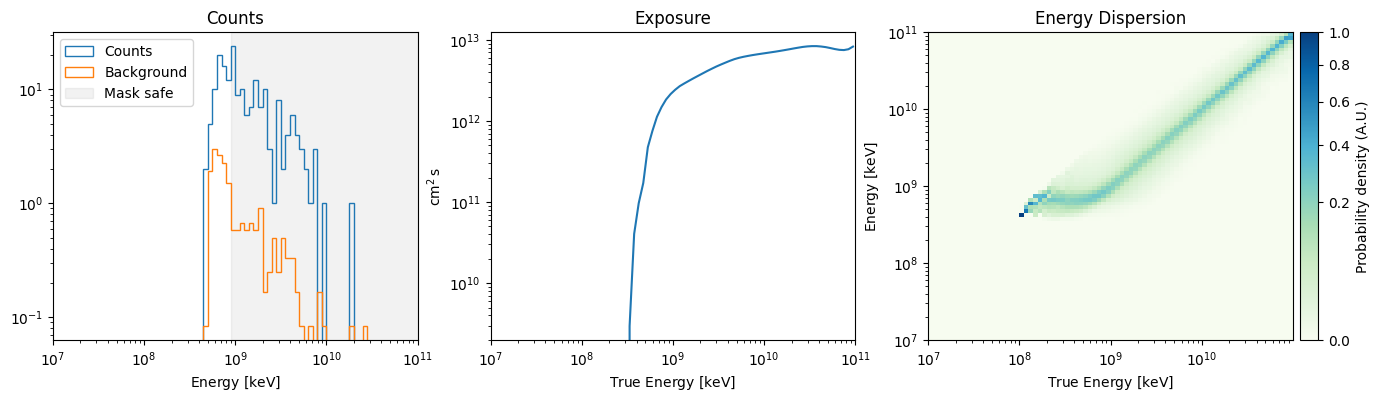

In [3]:
datasets[0].peek()

## Model definition

Now we want to define the spectral model that will be fitted to the
data.
The Crab spectra will be fitted here with as a powerlaw or a log parabola with prior of different strenght.
(names are qualitatives).


In [4]:
# create as set of alternative models with different spectral shape and prior strenght
from gammapy.modeling.models import create_crab_spectral_model, Models

alternative_models = {}
models_types = ["lp", "pl"]
# prior_types = ["uniformative"]
prior_types = ["uniformative", "magic-weak", "hess-weak"]

for model_type in models_types:
    for prior_type in prior_types:
        model_name = f"{model_type}({prior_type})"
        model = SkyModel.create(spectral_model=model_type, name=f"crab-{model_name}")
        model.spectral_model.reference.value = 1

        ref_model = create_crab_spectral_model("magic_lp")
        if "hess" in prior_type:
            ref_model_hess = create_crab_spectral_model("hess_pl")
            ref_model.alpha.value = ref_model_hess.index.value

        if model_type == "lp":
            if "uniformative" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-14, max=1e-8
                )
                model.spectral_model.alpha.prior = UniformPrior(min=0, max=10)
                model.spectral_model.beta.prior = UniformPrior(min=0, max=10)
            elif "weak" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-13, max=1e-9
                )
                model.spectral_model.alpha.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=2
                )
                model.spectral_model.beta.prior = UniformPrior(min=0, max=1)
            elif "strong" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-11, max=1e-10
                )
                model.spectral_model.alpha.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=0.1
                )
                model.spectral_model.beta.prior = GaussianPrior(
                    mu=ref_model.beta.value, sigma=0.1
                )
        elif model_type == "pl":
            if "uniformative" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-14, max=1e-8
                )
                model.spectral_model.index.prior = UniformPrior(min=0, max=10)
            elif "weak" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-13, max=1e-9
                )
                model.spectral_model.index.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=2
                )
            elif "strong" in prior_type:
                model.spectral_model.amplitude.prior = LogUniformPrior(
                    min=1e-11, max=1e-10
                )
                model.spectral_model.index.prior = GaussianPrior(
                    mu=ref_model.alpha.value, sigma=0.1
                )
        alternative_models[model_name] = Models(model)

alternative_models

{'lp(uniformative)': <gammapy.modeling.models.core.Models at 0x13533bf90>,
 'lp(magic-weak)': <gammapy.modeling.models.core.Models at 0x1356e1050>,
 'lp(hess-weak)': <gammapy.modeling.models.core.Models at 0x135758250>,
 'pl(uniformative)': <gammapy.modeling.models.core.Models at 0x135739910>,
 'pl(magic-weak)': <gammapy.modeling.models.core.Models at 0x135431d50>,
 'pl(hess-weak)': <gammapy.modeling.models.core.Models at 0x135749a10>}

## Defining the sampler and options


In [5]:
sampler_opts = {
    "live_points": 500,
    "frac_remain": 0.1,
    "log_dir": None,
}

sampler = Sampler(backend="ultranest", sampler_opts=sampler_opts)

## Defining the model selection manager

We define a `BayesianModelSelection` that will run the inference

In [6]:
from gammapy.modeling.selection import BayesianModelSelection

bms = BayesianModelSelection(
    sampler, prosterior_reduction_factor=4, n_prior_samples=1000
)

Next we can run the sampler on a given datasets for a set of alternative_models.
No other options are accepted in the run method.

## Test on simulations

### Simulation on Asimov dataset 

We can check the effect of prior on a simulated dataset where we know the true model. \
First we create a model with a power-law spectrum and we use it to create an Asimov dataset (counts=predicted counts, free of noise).

In [7]:
from gammapy.utils.random import get_random_state

model_name = "hess_pl"
spectral_model = create_crab_spectral_model(model_name)
model_simu = SkyModel(spectral_model=spectral_model, name=f"crab-{model_name}")

datasets.models = model_simu
datasets_asimov = datasets._to_asimov_datasets()

Then we run the model selection (we hide the ouptput with capture)

In [8]:
%%capture
bms_results = bms.run(datasets_asimov, alternative_models)

In [9]:
# lower => H0 is better
bms_results.stats_difference_table(reference_models_name="pl(uniformative)")

Model (prior),-2logz,-2logl,AIC,elpd (waic),elpd (loo),dof,waic eff. dof,loo eff. dof
str43,float64,float64,float64,float64,float64,int64,float64,float64
H0: pl(uniformative) - H1: lp(uniformative),-8.811,-0.009,-2.009,-0.920,-0.921,-1.000,-0.027,-0.028
H0: pl(uniformative) - H1: lp(magic-weak),-2.790,-0.012,-2.012,-0.934,-0.935,-1.000,-0.022,-0.023
H0: pl(uniformative) - H1: lp(hess-weak),-2.435,-0.005,-2.005,-1.111,-1.112,-1.000,-0.024,-0.024
H0: pl(uniformative) - H1: pl(magic-weak),1.996,-0.001,-0.001,0.077,0.077,0.000,0.003,0.003
H0: pl(uniformative) - H1: pl(hess-weak),2.332,-0.000,-0.000,0.122,0.122,0.000,0.002,0.002


Again the bayesian evidence can favor the wrong model if they are tested with stronger priors than the true model. 
While the ELPD always favor the true model and rank them as expected from their deviation to the true model (pl-hess).

<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

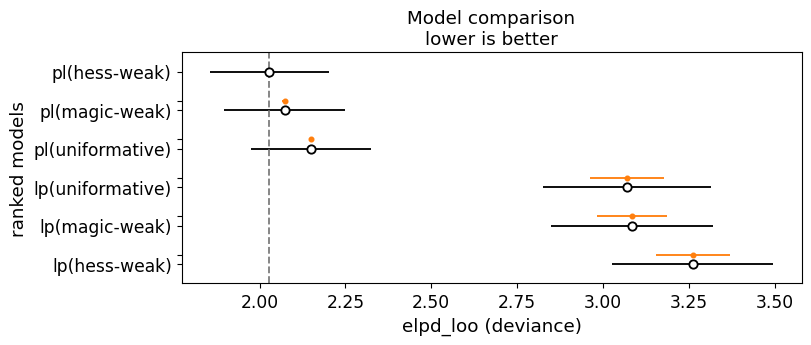

In [10]:
compare = bms_results.compare()
az.plot_compare(
    compare,
    figsize=(8, 3),
    plot_ic_diff=True,
    plot_kwargs={"marker_dse": ".", "color_dse": "C1"},
)

In [11]:
compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
pl(hess-weak),0,2.027907,0.027681,0.000000,0.215290,0.173444,0.000000,False,deviance
pl(magic-weak),1,2.072987,0.026166,0.045080,0.210506,0.175435,0.007332,False,deviance
pl(uniformative),2,2.149733,0.029478,0.121826,0.202592,0.174717,0.005580,False,deviance
lp(uniformative),3,3.070798,0.057558,1.042892,0.128070,0.244647,0.107758,False,deviance
lp(magic-weak),4,3.084564,0.052177,1.056657,0.127158,0.235998,0.103022,False,deviance
lp(hess-weak),5,3.262169,0.053552,1.234262,0.116385,0.234417,0.107542,False,deviance


### Simulations with noise

TODO: same dataset with noise try 1000 times in order to compare mean Monte-Carlo estimate with asimov dataset
elpd and elpd_err will be different, but heck if the mean of elpd difference and elpd_err difference tends to asimov result


In [12]:
datasets_fake = Datasets()
random_state = get_random_state("random-seed")
for d in datasets:
    npred_signal = d.npred_signal().copy()
    data = np.nan_to_num(npred_signal.data, copy=True, nan=0.0, posinf=0.0, neginf=0.0)
    npred_signal.data = random_state.poisson(data)
    npred_signal.data = npred_signal.data.astype("float")
    fake_dataset = d.__class__(
        models=d.models,
        counts=npred_signal + d.background,
        counts_off=d.counts_off,
        exposure=d.exposure,
        acceptance=d.acceptance,
        acceptance_off=d.acceptance_off,
        psf=d.psf,
        edisp=d.edisp,
        mask_safe=d.mask_safe,
        mask_fit=d.mask_fit,
        gti=d.gti,
        name=d.name,
        meta=d.meta,
    )
    datasets_fake.append(fake_dataset)